In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.svm import SVC

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector, Parameter
from qiskit.circuit.library import PauliFeatureMap
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel

import os
import shutil
def setup_latex_environment():
    tex_bin = "/sw/rl9c/texlive/2022/rl9_binary/install-tl-20221109/bin/x86_64-linux"
    if shutil.which("latex") or os.path.exists(tex_bin):
        os.environ["PATH"] = tex_bin + ":" + os.environ["PATH"]
        os.environ["TEXMFVAR"] = os.path.expanduser("~/.cache/texmf")
        print("LaTeX environment configured")
        print("latex:", shutil.which("latex"))
        print("dvipng:", shutil.which("dvipng"))
        print("gs:", shutil.which("gs"))
    else:
        print("LaTeX not found")

setup_latex_environment()

seed = 42
n_qubits = 4
n_train = 100
n_test = 50
rng = np.random.default_rng(seed)

LaTeX environment configured
latex: /sw/rl9c/texlive/2022/rl9_binary/install-tl-20221109/bin/x86_64-linux/latex
dvipng: /sw/rl9c/texlive/2022/rl9_binary/install-tl-20221109/bin/x86_64-linux/dvipng
gs: /usr/bin/gs


### Quantum feature map

We adopt the quantum feature map implemented in [1]. We build:

$$
\ket{\phi(x)} = U(\alpha;\mathbf{\theta})\ket{0}, \quad \alpha = \arccos(x)
$$

We start from the implementation for scalar data $x \in \mathbb{R}$.

In [57]:
def chebyshev_feature_map_scalar(n_layers=1, name="ChebyshevFeratureMap"):
    """
    Same circuit, but uses alpha = arccos(x) as the input parameter.
    This is the most practical Qiskit implementation.
    """
    alpha = Parameter("alpha")
    qc = QuantumCircuit(4, name=name)

    theta_blocks = []

    for layer in range(n_layers):
        theta = ParameterVector(f"θ{layer}", 8)
        theta_blocks.append(theta)

        qc.ry(theta[0], 0)
        qc.ry(theta[1], 1)
        qc.ry(theta[2], 2)
        qc.ry(theta[3], 3)

        qc.rx(theta[0] * alpha, 0)
        qc.rx(theta[1] * alpha, 1)
        qc.rx(theta[2] * alpha, 2)
        qc.rx(theta[3] * alpha, 3)

        qc.crz(theta[4], 0, 1)
        qc.crz(theta[5], 2, 3)
        qc.crz(theta[6], 1, 2)
        qc.crz(theta[7], 3, 0)

        qc.ry(theta[0], 0)
        qc.ry(theta[1], 1)
        qc.ry(theta[2], 2)
        qc.ry(theta[3], 3)

    return qc, alpha, theta_blocks

Now we see an example with a scalar qubit $x \in [-1,-1]$.

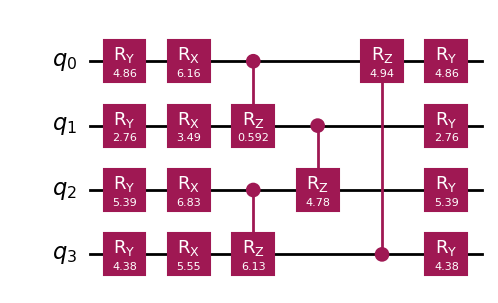

In [67]:
feature_map, alpha_param, theta_blocks = chebyshev_feature_map_scalar(n_layers=1)

x_value = 0.3
alpha_value = np.arccos(x_value)
rng = np.random.default_rng(seed)
theta_values = {}

for block in theta_blocks:
    vals = rng.uniform(0, 2*np.pi, size=len(block))
    for p, v in zip(block, vals):
        theta_values[p] = float(v)

bind_dict = {alpha_param: float(alpha_value), **theta_values}
bound_circuit = feature_map.assign_parameters(bind_dict)

bound_circuit.draw("mpl")

We also implement a version of the same circuit that accepts a vector $\mathbf{x} \in \mathbb{R}^d$ as input,

$$
\ket{\phi(\mathbf{x})} = U(\mathbf{\alpha};\mathbf{\theta})\ket{0}, \quad \mathbf{\alpha} = \arccos(\mathbf{x}) \in \mathbb{R}^d
$$

In [68]:
def chebyshev_feature_map_vector(
    n_qubits=4,
    n_layers=1,
    entanglement="ring",
    name="ChebyshevInspiredFM"
):
    """
    Generalized Chebyshev-inspired feature map.

    Each qubit i receives:
        Ry(theta_i) -> Rx(theta_i * alpha_i) -> entanglers -> Ry(theta_i)

    where alpha_i = arccos(x_i) is precomputed classically.

    Parameters
    ----------
    n_qubits : int
    n_layers : int
    entanglement : str
        "ring" or "linear"

    Returns
    -------
    qc : QuantumCircuit
    alpha : ParameterVector
        Input angles alpha_i = arccos(x_i)
    theta_blocks : list[ParameterVector]
        Per layer:
          first n_qubits params for local rotations
          then n_ent params for entanglers
    """
    alpha = ParameterVector("alpha", n_qubits)
    qc = QuantumCircuit(n_qubits, name=name)

    theta_blocks = []

    if entanglement == "ring":
        edges = [(i, (i + 1) % n_qubits) for i in range(n_qubits)]
    elif entanglement == "linear":
        edges = [(i, i + 1) for i in range(n_qubits - 1)]
    else:
        raise ValueError("entanglement must be 'ring' or 'linear'")

    n_ent = len(edges)

    for layer in range(n_layers):
        theta = ParameterVector(f"θ{layer}", n_qubits + n_ent)
        theta_blocks.append(theta)

        # Local trainable Ry
        for i in range(n_qubits):
            qc.ry(theta[i], i)

        # Data-dependent Rx(theta_i * alpha_i)
        for i in range(n_qubits):
            qc.rx(theta[i] * alpha[i], i)

        # Entanglers
        for j, (c, t) in enumerate(edges):
            qc.crz(theta[n_qubits + j], c, t)

        # Final trainable Ry
        for i in range(n_qubits):
            qc.ry(theta[i], i)

    return qc, alpha, theta_blocks

We see an example for a data point $\mathbf{x} \in \mathbb{R}^4$, where $x_i \in [-1,1]$:

Raw input vector x:
[ 0.2 -0.5  0.8  0.1]

Chebyshev-transformed angles alpha = arccos(x):
[1.36943841 2.0943951  0.64350111 1.47062891]


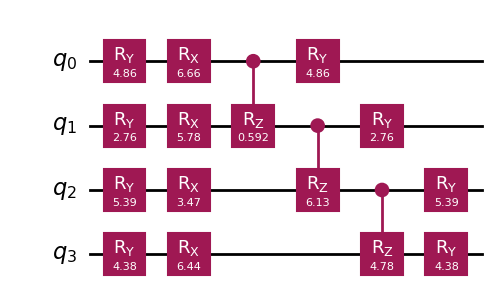

In [90]:
n_qubits = 4
feature_map, alpha_params, theta_blocks = chebyshev_feature_map_vector(
    n_qubits=n_qubits,
    n_layers=1,
    entanglement="linear"
)
x_vec = np.array([0.2, -0.5, 0.8, 0.1], dtype=float)
alpha_vec = np.arccos(x_vec)
print("Raw input vector x:")
print(x_vec)
print("\nChebyshev-transformed angles alpha = arccos(x):")
print(alpha_vec)
rng = np.random.default_rng(seed)
theta_values = {}

for block in theta_blocks:
    vals = rng.uniform(0, 2*np.pi, size=len(block))
    for p, v in zip(block, vals):
        theta_values[p] = float(v)

# Bind alpha_i and theta
bind_dict = {p: float(v) for p, v in zip(alpha_params, alpha_vec)}
bind_dict.update(theta_values)

bound_circuit = feature_map.assign_parameters(bind_dict)
bound_circuit.draw("mpl")

You take each input component $x_i$, convert it into an angle $\alpha_i = \arccos(x_i)$, use quantum rotations to turn those angles into nonlinear trigonometric responses, and then entangle the qubits so the final quantum state represents both individual features and their interactions. Now we display the probabilities of the vector state:

$$
\ket{\phi(\mathbf{x})} = \sum_{i=1}^{2^N} c_i\ket{i},
$$

where each $c_i \in \mathbb{C}$ and depends non-linearly on input $\mathbf{x}$.

[ 0.05881538+0.02390589j -0.08977577-0.28505949j -0.02748469+0.00610784j
  0.04594829-0.04195585j  0.12086103-0.01920495j -0.42874066-0.37994841j
 -0.0391753 +0.03462191j  0.04258559-0.10340793j  0.01532765+0.12805357j
  0.41462175-0.43978579j -0.03726725-0.03991722j  0.10815902+0.03064614j
  0.04151773+0.06612562j  0.11741054-0.34569955j -0.02960683-0.01579422j
  0.07386898+0.00656989j]


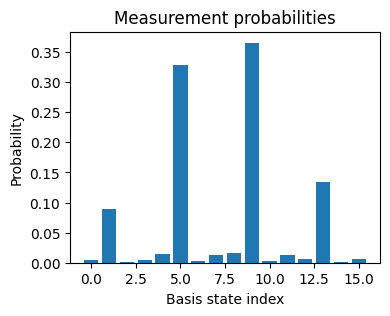

In [94]:
state = Statevector.from_instruction(bound_circuit)
print(state.data)
probs = np.abs(state.data) ** 2

plt.figure(figsize=(4,3))
plt.bar(range(len(probs)), probs)
plt.xlabel("Basis state index")
plt.ylabel("Probability")
plt.title("Measurement probabilities")
plt.show()

### Load `MNIST` dataset 

In [118]:
# Load OpenML MNIST
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist.data.astype(np.float64)
y = mnist.target

# Keep only 3 and 6
mask = np.isin(y, ["3", "6"])
X = X[mask]
y = y[mask]
y = np.where(y == "3", 0, 1).astype(int) # Binary labels: 3 -> 0, 6 -> 1

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=seed,
)

# Standardize original pixel space before PCA
pixel_scaler = StandardScaler()
X_train_full = pixel_scaler.fit_transform(X_train_full)
X_test_full = pixel_scaler.transform(X_test_full)

# PCA down to number of qubits
n_qubits = 8
pca = PCA(n_components=n_qubits, random_state=seed)
X_train_pca = pca.fit_transform(X_train_full)
X_test_pca = pca.transform(X_test_full)

# Scale to [-1,1] for arccos input to feature map
feature_map_scaler = MinMaxScaler(feature_range=(-1.0, 1.0))
X_train_pca = feature_map_scaler.fit_transform(X_train_pca)
X_test_pca = feature_map_scaler.transform(X_test_pca)
X_train_pca_alpha = np.arccos(np.clip(X_train_pca, -1.0, 1.0)) # np.clip to avoid numerical issues outside [-1,1]
X_test_pca_alpha = np.arccos(np.clip(X_test_pca, -1.0, 1.0))

# Subsample for manageable kernel-matrix size
# Balanced subset
def balanced_subset(X_arr, y_arr, n_samples_total):
    n_per_class = n_samples_total // 2
    idx0 = np.where(y_arr == 0)[0][:n_per_class]
    idx1 = np.where(y_arr == 1)[0][:n_per_class]
    idx = np.concatenate([idx0, idx1])
    return X_arr[idx], y_arr[idx]

X_train, y_train = balanced_subset(X_train_pca_alpha, y_train_full, n_train)
X_test, y_test = balanced_subset(X_test_pca_alpha, y_test_full, n_test)

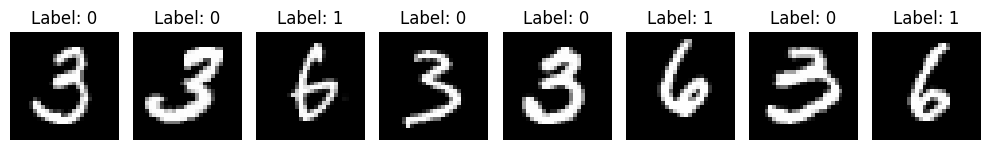

In [119]:
n_examples = 8
idx = np.random.choice(len(X), n_examples, replace=False)
plt.figure(figsize=(10, 2))
for i, j in enumerate(idx):
    plt.subplot(1, n_examples, i + 1)
    plt.imshow(X[j].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y[j]}")
    plt.axis("off")

#plt.suptitle("Example MNIST digits (3 vs 6)")
plt.tight_layout()
plt.show()

### Define a `FidelityQuantumKernel`

In [122]:
rng = np.random.default_rng(seed)
feature_map, alpha_params, theta_blocks = chebyshev_feature_map_vector(
    n_qubits=n_qubits,
    n_layers=1,
    entanglement="linear"
)
# Fix kernel parameters to random values for now (no optimization yet)
theta_bind = {}
for block in theta_blocks:
    vals = rng.uniform(0, 2*np.pi, size=len(block))
    for p, v in zip(block, vals):
        theta_bind[p] = float(v)

feature_map_fixed = feature_map.assign_parameters(theta_bind)
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map_fixed)

Now we compute the kernel matrix, which can then be used for algorithms like SVM.

In [123]:
K_train = quantum_kernel.evaluate(X_train)
K_test = quantum_kernel.evaluate(X_test, X_train)

print(K_train.shape, K_test.shape)

(100, 100) (50, 100)


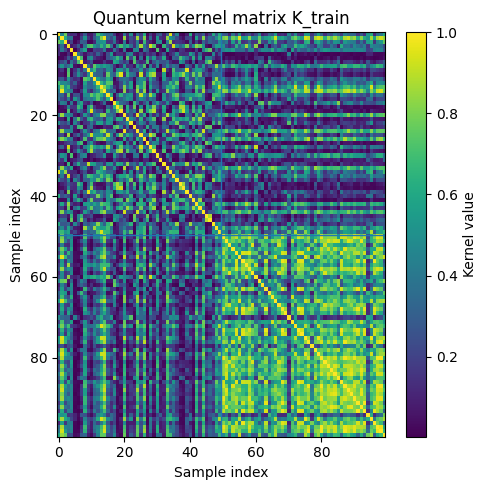

In [124]:
order = np.argsort(y_train)
K_train_sorted = K_train[order][:, order]
y_train_sorted = y_train[order]

plt.figure(figsize=(5, 5))
plt.imshow(K_train_sorted, interpolation="nearest", aspect="auto")
plt.colorbar(label="Kernel value")
plt.title("Quantum kernel matrix K_train")
plt.xlabel("Sample index")
plt.ylabel("Sample index")

boundary = np.sum(y_train_sorted == 0) - 0.5
plt.axhline(boundary, linewidth=1)
plt.axvline(boundary, linewidth=1)

plt.tight_layout()
plt.show()

In [ ]:
feature_map, alpha_params, theta_blocks = chebyshev_feature_map_vector(
    n_qubits=8,
    n_layers=1,
    entanglement="linear"
)

### SVM training

In [125]:
svm = SVC(kernel="precomputed", C=1.0)
svm.fit(K_train, y_train)

y_pred = svm.predict(K_test)

acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f}")

Test accuracy: 0.7400


### Another example

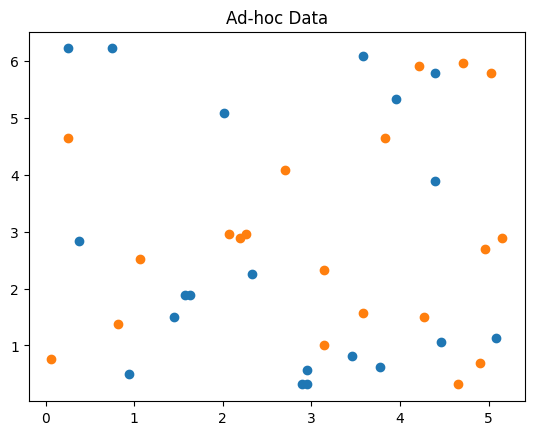

X_train shape: (40, 2)
y_train shape: (40,)
X_test shape: (20, 2)
y_test shape: (20,)
<PIL.Image.Image image mode=RGB size=1255x72 at 0x14D07246AE10>

Testing accuracy: 1.000

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



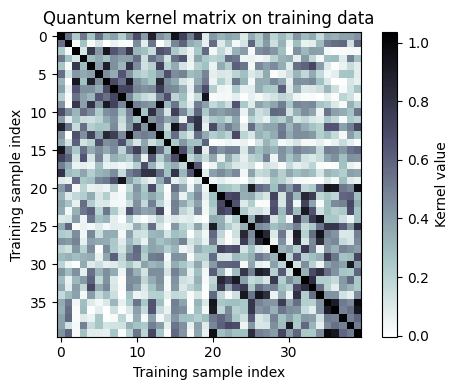

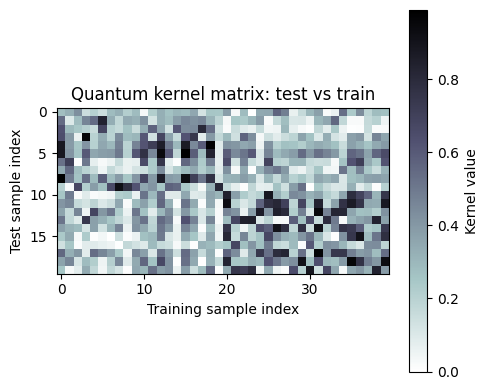


Ground truth:
['A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B']

Prediction:
['A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import StatevectorSampler

from qiskit_machine_learning.datasets import ad_hoc_data
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.utils import algorithm_globals

from sklearn.metrics import accuracy_score, classification_report


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
seed = 10598
algorithm_globals.random_seed = seed
np.random.seed(seed)


# ------------------------------------------------------------
# 1. Generate the toy ad hoc dataset
# This is the modern replacement for the old qsvm_datasets.ad_hoc_data.
# ------------------------------------------------------------
feature_dim = 2
training_size = 20
test_size = 10

X_train, y_train, X_test, y_test = ad_hoc_data(
    training_size=training_size,
    test_size=test_size,
    n=feature_dim,
    gap=0.3,
    plot_data=True,
    one_hot=False,
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


# ------------------------------------------------------------
# 2. Define the quantum feature map
# Old: SecondOrderExpansion(num_qubits=feature_dim, depth=2, ...)
# New: zz_feature_map(feature_dimension=feature_dim, reps=2, ...)
# ------------------------------------------------------------
feature_map = zz_feature_map(
    feature_dimension=feature_dim,
    reps=2,
    entanglement="linear",
)

print(feature_map.draw(output="latex", filename="circuit-latex.pdf"))


# ------------------------------------------------------------
# 3. Define the quantum kernel
# FidelityQuantumKernel computes:
# K(x, x') = |<phi(x)|phi(x')>|^2
# ------------------------------------------------------------
sampler = StatevectorSampler()
fidelity = ComputeUncompute(sampler=sampler)

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map,
    fidelity=fidelity,
    enforce_psd=True,
)


# ------------------------------------------------------------
# 4. Train a quantum support vector classifier
# This replaces the old QSVMKernel object.
# ------------------------------------------------------------
qsvc = QSVC(quantum_kernel=quantum_kernel)

qsvc.fit(X_train, y_train)

y_pred = qsvc.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"\nTesting accuracy: {test_accuracy:.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))


# ------------------------------------------------------------
# 5. Plot the training kernel matrix
# This reproduces the old "kernel matrix during training" block.
# ------------------------------------------------------------
K_train = quantum_kernel.evaluate(X_train)

plt.figure(figsize=(5, 4))
plt.imshow(K_train, interpolation="nearest", origin="upper", cmap="bone_r")
plt.colorbar(label="Kernel value")
plt.title(r"K_{XX}")
plt.xlabel("Training sample index")
plt.ylabel("Training sample index")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Optional: evaluate test kernel matrix
# ------------------------------------------------------------
K_test = quantum_kernel.evaluate(X_test, X_train)

plt.figure(figsize=(5, 4))
plt.imshow(K_test, interpolation="nearest", origin="upper", cmap="bone_r")
plt.colorbar(label="Kernel value")
plt.title("Quantum kernel matrix: test vs train")
plt.xlabel("Training sample index")
plt.ylabel("Test sample index")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Print predictions in a style similar to the old tutorial
# ------------------------------------------------------------
label_names = {0: "A", 1: "B", -1: "A", 1: "B"}

ground_truth = [label_names.get(int(y), str(y)) for y in y_test]
prediction = [label_names.get(int(y), str(y)) for y in y_pred]

print("\nGround truth:")
print(ground_truth)

print("\nPrediction:")
print(prediction)

X_train shape: (40, 2)
X_test shape: (20, 2)

Testing accuracy: 0.800

Classification report:
              precision    recall  f1-score   support

   malignant       1.00      0.43      0.60         7
      benign       0.76      1.00      0.87        13

    accuracy                           0.80        20
   macro avg       0.88      0.71      0.73        20
weighted avg       0.85      0.80      0.77        20



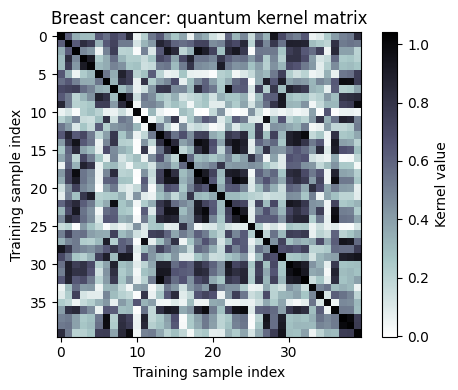

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report

from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import StatevectorSampler

from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.utils import algorithm_globals


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
seed = 10598
algorithm_globals.random_seed = seed
np.random.seed(seed)


# ------------------------------------------------------------
# 1. Load breast cancer dataset
# ------------------------------------------------------------
data = load_breast_cancer()
X = data.data
y = data.target


# ------------------------------------------------------------
# 2. Standardize, reduce to 2 PCA dimensions, then scale to [0, pi]
# Quantum feature maps usually expect compact angular input ranges.
# ------------------------------------------------------------
X = StandardScaler().fit_transform(X)
X = PCA(n_components=2, random_state=seed).fit_transform(X)
X = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(X)


# ------------------------------------------------------------
# 3. Small subset, similar to the original tutorial
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=40,
    test_size=20,
    random_state=seed,
    stratify=y,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


# ------------------------------------------------------------
# 4. Quantum kernel classifier
# ------------------------------------------------------------
feature_dim = 2

feature_map = zz_feature_map(
    feature_dimension=feature_dim,
    reps=2,
    entanglement="linear",
)

sampler = StatevectorSampler()
fidelity = ComputeUncompute(sampler=sampler)

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map,
    fidelity=fidelity,
    enforce_psd=True,
)

qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train, y_train)

y_pred = qsvc.predict(X_test)

print(f"\nTesting accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))


# ------------------------------------------------------------
# 5. Plot kernel matrix
# ------------------------------------------------------------
K_train = quantum_kernel.evaluate(X_train)

plt.figure(figsize=(5, 4))
plt.imshow(K_train, interpolation="nearest", origin="upper", cmap="bone_r")
plt.colorbar(label="Kernel value")
plt.title("Breast cancer: quantum kernel matrix")
plt.xlabel("Training sample index")
plt.ylabel("Training sample index")
plt.tight_layout()
plt.show()

### References

[1] Rapp, Frederic, and Marco Roth. "Quantum Gaussian process regression for Bayesian optimization." Quantum Machine Intelligence 6, no. 1 (2024): 5.